# Cosmos 3 Nano Reasoner — MMAD Combined Analysis

This executed notebook combines:

1. **229 questions** from the official NVIDIA Build Experience UI.
2. **393 questions** from the community Reasoner-only BNB8 checkpoint on Kaggle T4×2.

Both segments use the same canonical MMAD manifest. They are kept as separate `segment` values because the serving backend and numerical precision differ. The aggregate is useful for operational inspection, but **must not be reported as a single homogeneous model leaderboard score**.


In [ ]:
from pathlib import Path
import json, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)

ROOT = Path.cwd()
candidates = [ROOT / 'research/mmad_model_benchmark/outputs/cosmos3_combined/predictions_combined.jsonl']
candidates += list(ROOT.rglob('cosmos3_combined/predictions_combined.jsonl'))
PREDICTIONS = next(p for p in candidates if p.exists())
rows = [json.loads(x) for x in PREDICTIONS.read_text(encoding='utf-8').splitlines() if x.strip()]
df = pd.json_normalize(rows, sep='.')
df['has_answer'] = df.prediction.isin(list('ABCD'))
df['correct'] = df['correct'].fillna(False).astype(bool)
reasoning_fallback = df.reasoning.fillna('').str.len()
response_fallback = df.response.fillna('').str.len()
df['reasoning_chars'] = df.get(
    'reasoning_chars', pd.Series(index=df.index, dtype=float)
).fillna(reasoning_fallback)
df['response_chars'] = df.get(
    'response_chars', pd.Series(index=df.index, dtype=float)
).fillna(response_fallback)
df['is_normal'] = df['is_normal'].map(lambda x: {'True': True, 'False': False}.get(str(x), x))
print('Source:', PREDICTIONS)
print('Rows:', len(df), '| Manifest:', df.manifest_sha256.nunique(), 'unique hash')
display(df[['segment','question_number','sample_id','status','prediction','ground_truth','correct']].head())


Source: C:\Users\ASUS\OneDrive\Desktop\Jarvis-Vision\research\mmad_model_benchmark\outputs\cosmos3_combined\predictions_combined.jsonl
Rows: 622 | Manifest: 1 unique hash


,segment,question_number,sample_id,status,prediction,ground_truth,correct
0,NVIDIA Build UI (official endpoint),1,mmad_full_00001,ok,A,A,True
1,NVIDIA Build UI (official endpoint),2,mmad_full_00002,no_output,None,A,False
2,NVIDIA Build UI (official endpoint),3,mmad_full_00003,ok,B,B,True
3,NVIDIA Build UI (official endpoint),4,mmad_full_00004,ok,B,A,False
4,NVIDIA Build UI (official endpoint),5,mmad_full_00005,ok,A,A,True


## 1. Integrity and merge audit

In [ ]:
def wilson(k, n, z=1.96):
    if not n: return (np.nan, np.nan)
    p=k/n; den=1+z*z/n
    center=(p+z*z/(2*n))/den
    half=z*math.sqrt((p*(1-p)+z*z/(4*n))/n)/den
    return center-half, center+half

def summarize(frame, key=None):
    groups = [('All merged records', frame)] if key is None else frame.groupby(key, dropna=False)
    out=[]
    for name,g in groups:
        answered=int(g.has_answer.sum()); correct=int(g.correct.sum())
        lo,hi=wilson(correct, answered)
        out.append({
            key or 'scope': name, 'n':len(g), 'answered':answered,
            'coverage':answered/len(g), 'correct':correct,
            'conditional_accuracy':correct/answered if answered else np.nan,
            'accuracy_ci_low':lo, 'accuracy_ci_high':hi,
            'effective_accuracy':correct/len(g),
            'mean_latency_s':g.latency_seconds.mean(),
            'median_latency_s':g.latency_seconds.median(),
        })
    return pd.DataFrame(out)


In [ ]:
audit = pd.DataFrame({
    'item':['Rows','Unique sample IDs','Unique question numbers','Duplicate sample IDs',
            'Manifest hashes','Min question','Max question','Question-index gaps'],
    'value':[len(df),df.sample_id.nunique(),df.question_number.nunique(),
             len(df)-df.sample_id.nunique(),df.manifest_sha256.nunique(),
             int(df.question_number.min()),int(df.question_number.max()),
             int(df.question_number.max()-df.question_number.min()+1-df.question_number.nunique())]
})
display(audit)
display(df.groupby('segment').agg(
    records=('sample_id','size'), min_question=('question_number','min'),
    max_question=('question_number','max'), unique_questions=('question_number','nunique')
).reset_index())
assert df.sample_id.is_unique
assert df.manifest_sha256.nunique() == 1


,item,value
0,Rows,622
1,Unique sample IDs,622
2,Unique question numbers,622
3,Duplicate sample IDs,0
4,Manifest hashes,1
5,Min question,1
6,Max question,30795
7,Question-index gaps,30173


,segment,records,min_question,max_question,unique_questions
0,Kaggle T4x2 (community BNB8),393,230,30795,393
1,NVIDIA Build UI (official endpoint),229,1,229,229


## 2. Backend-aware coverage and accuracy

,scope,n,answered,coverage,correct,conditional_accuracy,accuracy_ci_low,accuracy_ci_high,effective_accuracy,mean_latency_s,median_latency_s
0,All merged records,622,601,96.6%,388,64.6%,60.7%,68.3%,62.4%,42.313828,42.424700


,segment,n,answered,coverage,correct,conditional_accuracy,accuracy_ci_low,accuracy_ci_high,effective_accuracy,mean_latency_s,median_latency_s
0,Kaggle T4x2 (community BNB8),393,380,96.7%,278,73.2%,68.5%,77.4%,70.7%,54.735982,47.968100
1,NVIDIA Build UI (official endpoint),229,221,96.5%,110,49.8%,43.2%,56.3%,48.0%,20.995459,8.182000


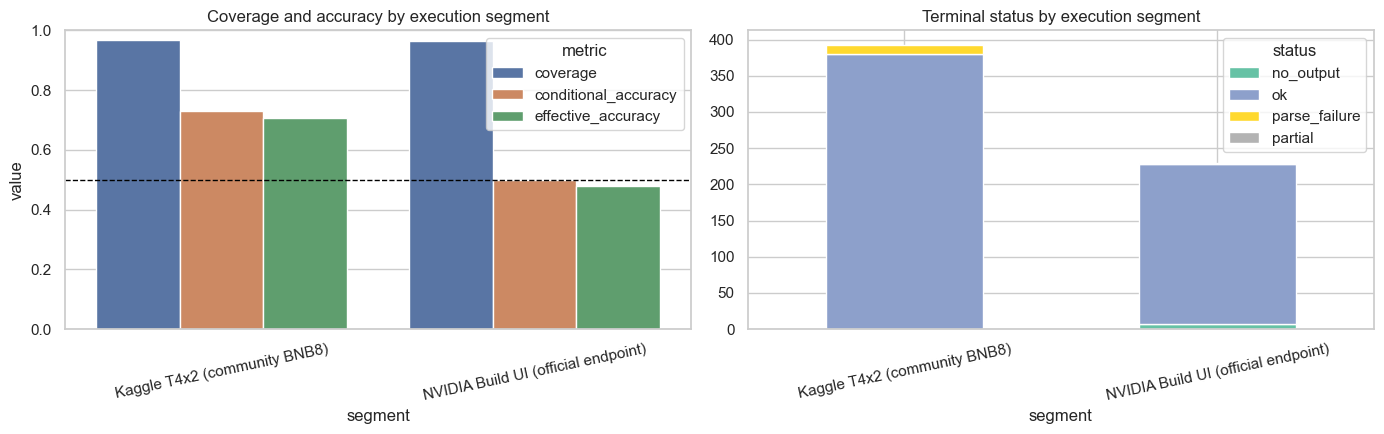

In [ ]:
overall = summarize(df)
by_segment = summarize(df, 'segment')
display(overall.style.format({c:'{:.1%}' for c in ['coverage','conditional_accuracy','accuracy_ci_low','accuracy_ci_high','effective_accuracy']}))
display(by_segment.style.format({c:'{:.1%}' for c in ['coverage','conditional_accuracy','accuracy_ci_low','accuracy_ci_high','effective_accuracy']}))

fig, axes = plt.subplots(1,2,figsize=(14,4.5))
plot=by_segment.melt(id_vars='segment',value_vars=['coverage','conditional_accuracy','effective_accuracy'],
                     var_name='metric',value_name='value')
sns.barplot(data=plot,x='segment',y='value',hue='metric',ax=axes[0])
axes[0].axhline(.5,color='black',ls='--',lw=1); axes[0].set_ylim(0,1)
axes[0].set_title('Coverage and accuracy by execution segment'); axes[0].tick_params(axis='x',rotation=12)
status=pd.crosstab(df.segment,df.status)
status.plot(kind='bar',stacked=True,ax=axes[1],colormap='Set2')
axes[1].set_title('Terminal status by execution segment'); axes[1].tick_params(axis='x',rotation=12)
plt.tight_layout(); plt.show()


## 3. Capability, source and category slices

,question_type,n,answered,coverage,correct,conditional_accuracy,accuracy_ci_low,accuracy_ci_high,effective_accuracy,mean_latency_s,median_latency_s
0,Anomaly Detection,308,300,97.4%,141,47.0%,41.4%,52.7%,45.8%,27.709116,8.288000
2,Defect Classification,56,48,85.7%,29,60.4%,46.3%,73.0%,51.8%,64.615602,55.107450
3,Defect Description,55,54,98.2%,41,75.9%,63.1%,85.4%,74.5%,52.683084,44.972900
4,Defect Localization,56,56,100.0%,46,82.1%,70.2%,90.0%,82.1%,48.666952,42.756450
1,Defect Analysis,55,53,96.4%,45,84.9%,72.9%,92.1%,81.8%,68.971562,63.731800
5,Object Analysis,69,67,97.1%,63,94.0%,85.6%,97.7%,91.3%,49.010687,44.250200
6,Object Classification,23,23,100.0%,23,100.0%,85.7%,100.0%,100.0%,59.488148,57.521800


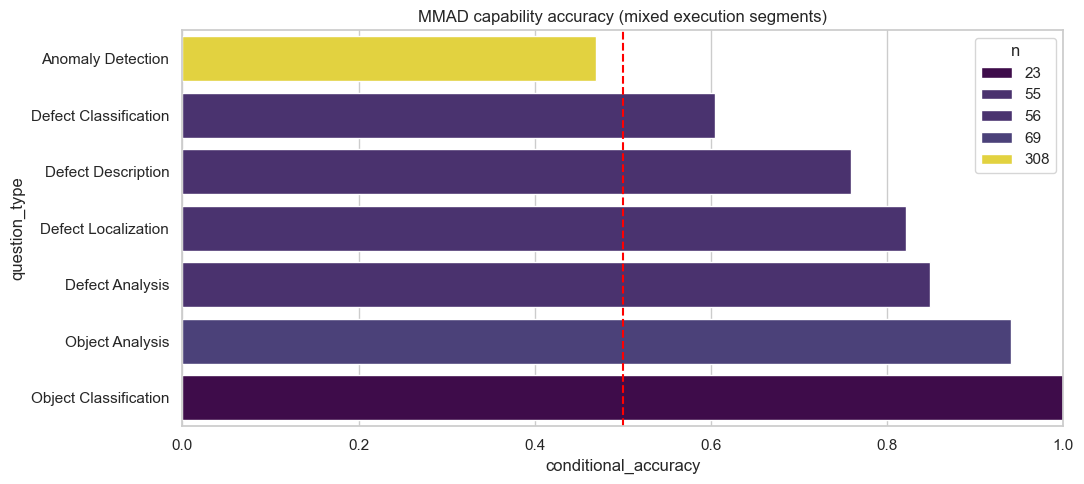

,source_dataset,n,answered,coverage,correct,conditional_accuracy,accuracy_ci_low,accuracy_ci_high,effective_accuracy,mean_latency_s,median_latency_s
0,MVTec-AD,622,601,96.6%,388,64.6%,0.606534,0.682798,62.4%,42.313828,42.424700


,category,n,answered,coverage,correct,conditional_accuracy,accuracy_ci_low,accuracy_ci_high,effective_accuracy,mean_latency_s,median_latency_s
1,cable,166,157,94.6%,67,42.7%,0.352042,0.504960,40.4%,15.375788,8.176500
0,bottle,83,81,97.6%,54,66.7%,0.558526,0.759714,65.1%,42.907060,61.828000
2,capsule,373,363,97.3%,267,73.6%,0.687870,0.778272,71.6%,54.170333,47.203900


In [ ]:
task_metrics=summarize(df,'question_type').sort_values('conditional_accuracy')
display(task_metrics.style.format({c:'{:.1%}' for c in ['coverage','conditional_accuracy','accuracy_ci_low','accuracy_ci_high','effective_accuracy']}))

fig,ax=plt.subplots(figsize=(11,5))
sns.barplot(data=task_metrics,x='conditional_accuracy',y='question_type',hue='n',palette='viridis',ax=ax)
ax.axvline(.5,color='red',ls='--',label='binary baseline'); ax.set_xlim(0,1)
ax.set_title('MMAD capability accuracy (mixed execution segments)')
plt.tight_layout(); plt.show()

source_metrics=summarize(df,'source_dataset').sort_values('conditional_accuracy')
category_metrics=summarize(df,'category').sort_values('conditional_accuracy')
display(source_metrics.style.format({c:'{:.1%}' for c in ['coverage','conditional_accuracy','effective_accuracy']}))
display(category_metrics.style.format({c:'{:.1%}' for c in ['coverage','conditional_accuracy','effective_accuracy']}))


## 4. Anomaly-detection failure analysis

,is_normal,n,answered,coverage,correct,conditional_accuracy,accuracy_ci_low,accuracy_ci_high,effective_accuracy,mean_latency_s,median_latency_s
0,False,207,202,97.6%,45,22.3%,0.170866,0.285026,21.7%,32.778814,36.581600
1,True,101,98,97.0%,96,98.0%,0.928616,0.994386,95.0%,17.318746,8.181000


prediction,A,B
ground_truth,,
A,78,82
B,77,63


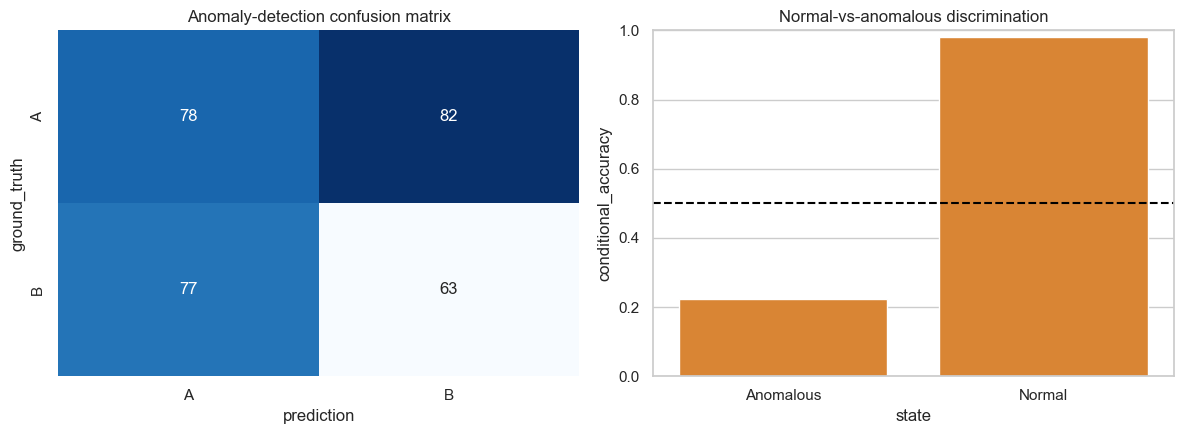

In [ ]:
anom=df[df.question_type.eq('Anomaly Detection')].copy()
state_metrics=summarize(anom,'is_normal')
display(state_metrics.style.format({c:'{:.1%}' for c in ['coverage','conditional_accuracy','effective_accuracy']}))

answered=anom[anom.has_answer]
cm=pd.crosstab(answered.ground_truth,answered.prediction).reindex(index=['A','B'],columns=['A','B'],fill_value=0)
display(cm)
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False,ax=axes[0])
axes[0].set_title('Anomaly-detection confusion matrix')
state_plot=state_metrics.copy()
state_plot['state']=state_plot.is_normal.map({True:'Normal',False:'Anomalous'})
sns.barplot(data=state_plot,x='state',y='conditional_accuracy',ax=axes[1],color='#F58518')
axes[1].axhline(.5,color='black',ls='--'); axes[1].set_ylim(0,1)
axes[1].set_title('Normal-vs-anomalous discrimination')
plt.tight_layout(); plt.show()


## 5. Latency and reasoning capture

,segment,count,mean,median,min,max
0,Kaggle T4x2 (community BNB8),393,54.735982,47.9681,16.4666,116.2547
1,NVIDIA Build UI (official endpoint),229,20.995459,8.1820,6.1360,61.9940


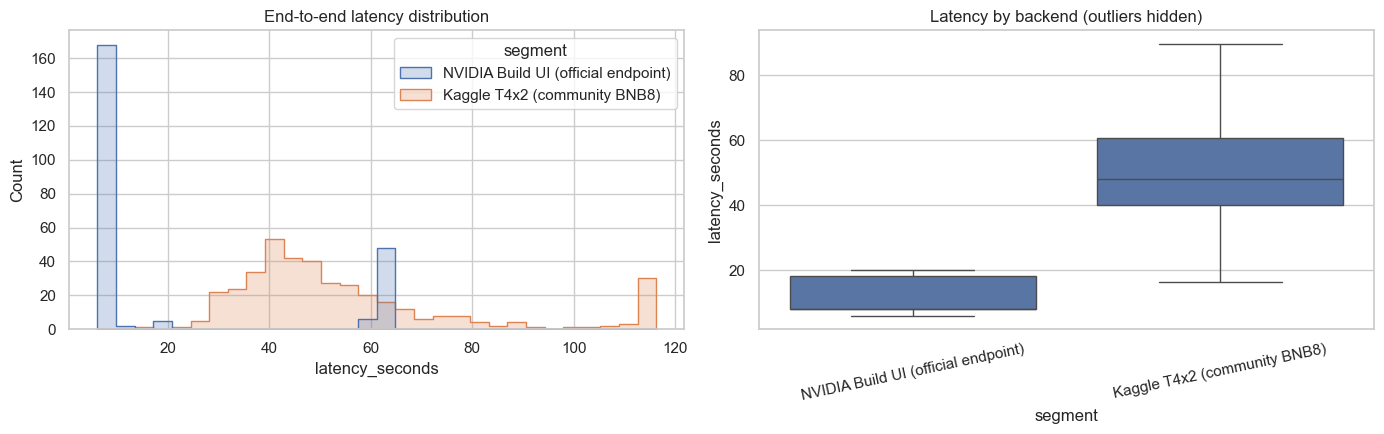

,segment,answers,reasoning_present,median_reasoning_chars,median_response_chars
0,Kaggle T4x2 (community BNB8),380,0.950000,879.5,1.0
1,NVIDIA Build UI (official endpoint),221,0.986425,1259.0,1.0


In [ ]:
latency=df.groupby('segment').latency_seconds.agg(['count','mean','median','min','max']).reset_index()
display(latency)
fig,axes=plt.subplots(1,2,figsize=(14,4.5))
sns.histplot(data=df,x='latency_seconds',hue='segment',bins=30,element='step',ax=axes[0])
axes[0].set_title('End-to-end latency distribution')
sns.boxplot(data=df,x='segment',y='latency_seconds',showfliers=False,ax=axes[1])
axes[1].tick_params(axis='x',rotation=12); axes[1].set_title('Latency by backend (outliers hidden)')
plt.tight_layout(); plt.show()

reason=df[df.has_answer].copy()
reason['reasoning_present']=reason.reasoning_chars.gt(0)
capture=reason.groupby('segment').agg(
    answers=('sample_id','size'), reasoning_present=('reasoning_present','mean'),
    median_reasoning_chars=('reasoning_chars','median'),
    median_response_chars=('response_chars','median')
).reset_index()
display(capture)


## 6. Canonical question-index coverage

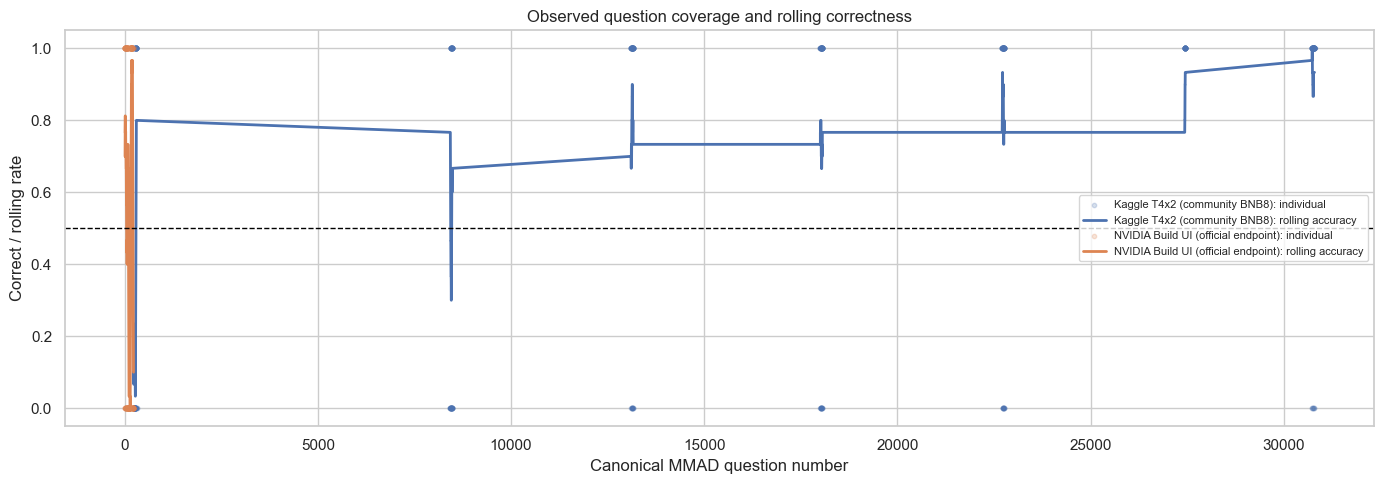

,segment,question_type,n,accuracy,coverage
0,Kaggle T4x2 (community BNB8),Anomaly Detection,79,0.392405,1.000000
1,Kaggle T4x2 (community BNB8),Defect Analysis,55,0.818182,0.963636
2,Kaggle T4x2 (community BNB8),Defect Classification,56,0.517857,0.857143
3,Kaggle T4x2 (community BNB8),Defect Description,55,0.745455,0.981818
4,Kaggle T4x2 (community BNB8),Defect Localization,56,0.821429,1.000000
5,Kaggle T4x2 (community BNB8),Object Analysis,69,0.913043,0.971014
6,Kaggle T4x2 (community BNB8),Object Classification,23,1.000000,1.000000
7,NVIDIA Build UI (official endpoint),Anomaly Detection,229,0.480349,0.965066


In [ ]:
ordered=df.sort_values('question_number').copy()
ordered['rolling_accuracy_30']=ordered.correct.rolling(30,min_periods=10).mean()
ordered['rolling_coverage_30']=ordered.has_answer.rolling(30,min_periods=10).mean()
fig,ax=plt.subplots(figsize=(14,5))
for segment,g in ordered.groupby('segment'):
    ax.scatter(g.question_number,g.correct.astype(float),s=10,alpha=.22,label=f'{segment}: individual')
    ax.plot(g.question_number,g.rolling_accuracy_30,lw=2,label=f'{segment}: rolling accuracy')
ax.axhline(.5,color='black',ls='--',lw=1)
ax.set(title='Observed question coverage and rolling correctness',xlabel='Canonical MMAD question number',ylabel='Correct / rolling rate',ylim=(-.05,1.05))
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

display(ordered.groupby(['segment','question_type']).agg(
    n=('sample_id','size'), accuracy=('correct','mean'), coverage=('has_answer','mean')
).reset_index())


## 7. Automatic conclusion

In [ ]:
seg=by_segment.set_index('segment')
ui=seg.loc['NVIDIA Build UI (official endpoint)']
kg=seg.loc['Kaggle T4x2 (community BNB8)']
weak=task_metrics.iloc[0]
strong=task_metrics.iloc[-1]
anom_state=state_metrics.set_index('is_normal')

text=f'''### Executive conclusion

- The merged corpus contains **{len(df)} unique MMAD questions**: 229 from NVIDIA Build and 393 from Kaggle T4×2.
- NVIDIA Build achieved **{ui.conditional_accuracy:.1%} conditional accuracy** with **{ui.coverage:.1%} coverage**. The Kaggle BNB8 segment achieved **{kg.conditional_accuracy:.1%} conditional accuracy** with **{kg.coverage:.1%} coverage**.
- The weakest observed capability is **{weak.question_type}** at **{weak.conditional_accuracy:.1%}** (n={int(weak.n)}); the strongest is **{strong.question_type}** at **{strong.conditional_accuracy:.1%}** (n={int(strong.n)}).
- In anomaly detection, normal and anomalous samples remain highly asymmetric. This is the key failure mode, not merely answer parsing.
- The Kaggle records are non-contiguous and currently cover only selected image groups. The combined set is therefore **diagnostic, not a valid full-MMAD leaderboard result**.
- Because the two segments use different backends and precision, compare their rows separately. The aggregate is useful only as an operational evidence pool.
'''
display(Markdown(text))


### Executive conclusion

- The merged corpus contains **622 unique MMAD questions**: 229 from NVIDIA Build and 393 from Kaggle T4×2.
- NVIDIA Build achieved **49.8% conditional accuracy** with **96.5% coverage**. The Kaggle BNB8 segment achieved **73.2% conditional accuracy** with **96.7% coverage**.
- The weakest observed capability is **Anomaly Detection** at **47.0%** (n=308); the strongest is **Object Classification** at **100.0%** (n=23).
- In anomaly detection, normal and anomalous samples remain highly asymmetric. This is the key failure mode, not merely answer parsing.
- The Kaggle records are non-contiguous and currently cover only selected image groups. The combined set is therefore **diagnostic, not a valid full-MMAD leaderboard result**.
- Because the two segments use different backends and precision, compare their rows separately. The aggregate is useful only as an operational evidence pool.


## 8. Export analysis artifacts

In [ ]:
out=PREDICTIONS.parent
by_segment.to_csv(out/'analysis_by_segment.csv',index=False)
task_metrics.to_csv(out/'analysis_by_task.csv',index=False)
source_metrics.to_csv(out/'analysis_by_source.csv',index=False)
category_metrics.to_csv(out/'analysis_by_category.csv',index=False)

report={
    'records':int(len(df)),
    'manifest_sha256':str(df.manifest_sha256.iloc[0]),
    'mixed_backend_warning':True,
    'by_segment':by_segment.replace({np.nan:None}).to_dict('records'),
    'by_task':task_metrics.replace({np.nan:None}).to_dict('records'),
}
(out/'analysis_summary.json').write_text(json.dumps(report,indent=2,ensure_ascii=False),encoding='utf-8')
print('Saved analysis tables and summary to:',out)


Saved analysis tables and summary to: C:\Users\ASUS\OneDrive\Desktop\Jarvis-Vision\research\mmad_model_benchmark\outputs\cosmos3_combined
